In [1]:
# =========================================
# 02_build_architecture_features.ipynb
# Build architecture / stack / core physical features
# =========================================

import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

RAW_FILE = os.path.join(WORK_DIR, "Perovskite_database_content_all_data.csv")
LABEL_FILE = os.path.join(WORK_DIR, "interim", "t80_labels.parquet")

ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "02_architecture")
INTERIM_DIR = os.path.join(WORK_DIR, "interim")
META_DIR = os.path.join(WORK_DIR, "metadata")
REPORT_DIR = os.path.join(WORK_DIR, "reports")

for p in [ARTIFACT_DIR, INTERIM_DIR, META_DIR, REPORT_DIR]:
    os.makedirs(p, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("RAW_FILE:", RAW_FILE)
print("LABEL_FILE:", LABEL_FILE)

WORK_DIR: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026
RAW_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\Perovskite_database_content_all_data.csv
LABEL_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\t80_labels.parquet


In [2]:
df = pd.read_csv(RAW_FILE, low_memory=False)
labels_t80 = pd.read_parquet(LABEL_FILE)

print("Raw shape:", df.shape)
print("T80 labels shape:", labels_t80.shape)

df.head(2)

Raw shape: (43398, 410)
T80 labels shape: (1835, 11)


,Ref_ID,Ref_ID_temp,Ref_name_of_person_entering_the_data,Ref_data_entered_by_author,Ref_DOI_number,Ref_lead_author,Ref_publication_date,Ref_journal,Ref_part_of_initial_dataset,Ref_original_filename_data_upload,Ref_free_text_comment,Ref_internal_sample_id,Cell_stack_sequence,Cell_area_total,Cell_area_measured,Cell_number_of_cells_per_substrate,Cell_architecture,Cell_flexible,Cell_flexible_min_bending_radius,Cell_semitransparent,Cell_semitransparent_AVT,Cell_semitransparent_wavelength_range,Cell_semitransparent_raw_data,Module,Module_number_of_cells_in_module,Module_area_total,Module_area_effective,Module_JV_data_recalculated_per_cell,Substrate_stack_sequence,Substrate_thickness,Substrate_area,Substrate_supplier,Substrate_brand_name,Substrate_deposition_procedure,Substrate_surface_roughness_rms,Substrate_etching_procedure,Substrate_cleaning_procedure,ETL_stack_sequence,ETL_thickness,ETL_additives_compounds,ETL_additives_concentrations,ETL_deposition_procedure,ETL_deposition_aggregation_state_of_reactants,ETL_deposition_synthesis_atmosphere,ETL_deposition_synthesis_atmosphere_pressure_total,ETL_deposition_synthesis_atmosphere_pressure_partial,ETL_deposition_synthesis_atmosphere_relative_humidity,ETL_deposition_solvents,ETL_deposition_solvents_mixing_ratios,ETL_deposition_solvents_supplier,ETL_deposition_solvents_purity,ETL_deposition_reaction_solutions_compounds,ETL_deposition_reaction_solutions_compounds_supplier,ETL_deposition_reaction_solutions_compounds_purity,ETL_deposition_reaction_solutions_concentrations,ETL_deposition_reaction_solutions_volumes,ETL_deposition_reaction_solutions_age,ETL_deposition_reaction_solutions_temperature,ETL_deposition_substrate_temperature,ETL_deposition_thermal_annealing_temperature,ETL_deposition_thermal_annealing_time,ETL_deposition_thermal_annealing_atmosphere,ETL_storage_time_until_next_deposition_step,ETL_storage_atmosphere,ETL_storage_relative_humidity,ETL_surface_treatment_before_next_deposition_step,Perovskite_single_crystal,Perovskite_dimension_0D,Perovskite_dimension_2D,Perovskite_dimension_2D3D_mixture,Perovskite_dimension_3D,Perovskite_dimension_3D_with_2D_capping_layer,Perovskite_dimension_list_of_layers,Perovskite_composition_perovskite_ABC3_structure,Perovskite_composition_perovskite_inspired_structure,Perovskite_composition_a_ions,Perovskite_composition_a_ions_coefficients,Perovskite_composition_b_ions,Perovskite_composition_b_ions_coefficients,Perovskite_composition_c_ions,Perovskite_composition_c_ions_coefficients,Perovskite_composition_none_stoichiometry_components_in_excess,Perovskite_composition_short_form,Perovskite_composition_long_form,Perovskite_composition_assumption,Perovskite_composition_inorganic,Perovskite_composition_leadfree,Perovskite_additives_compounds,Perovskite_additives_concentrations,Perovskite_thickness,Perovskite_band_gap,Perovskite_band_gap_graded,Perovskite_band_gap_estimation_basis,Perovskite_pl_max,Perovskite_deposition_number_of_deposition_steps,Perovskite_deposition_procedure,Perovskite_deposition_aggregation_state_of_reactants,Perovskite_deposition_synthesis_atmosphere,Perovskite_deposition_synthesis_atmosphere_pressure_total,Perovskite_deposition_synthesis_atmosphere_pressure_partial,...,JV_default_Jsc_scan_direction,JV_default_FF_scan_direction,JV_default_PCE_scan_direction,JV_hysteresis_index,Stabilised_performance_measured,Stabilised_performance_procedure,Stabilised_performance_procedure_metrics,Stabilised_performance_measurement_time,Stabilised_performance_PCE,Stabilised_performance_Vmp,Stabilised_performance_Jmp,Stabilised_performance_link_raw_data,EQE_measured,EQE_light_bias,EQE_integrated_Jsc,EQE_link_raw_data,Stability_measured,Stability_protocol,Stability_average_over_n_number_of_cells,Stability_light_source_type,Stability_light_source_brand_name,Stability_light_source_simulator_class,Stability_light_intensity,Stability_light_spectra,Stability_light_wavelength_range,Stability_light_illumination_direction,Stability_light_load_condition,Stab

In [3]:
if "raw_row_id" not in labels_t80.columns:
    raise ValueError("labels_t80 must contain raw_row_id from Notebook 01.")

raw_join = df.copy()
raw_join["raw_row_id"] = np.arange(len(raw_join))

t80_df = labels_t80.merge(
    raw_join,
    on="raw_row_id",
    how="left",
    suffixes=("", "_rawdup")
)

print("Merged T80 feature table shape:", t80_df.shape)
print("Rows with missing raw join:", t80_df.isna().all(axis=1).sum())
t80_df.head(2)

Merged T80 feature table shape: (1835, 421)
Rows with missing raw join: 0


,raw_row_id,Ref_DOI_number,Ref_publication_date,publication_year,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,T80_raw,T80_clean,T80_log1p,Ref_ID,Ref_ID_temp,Ref_name_of_person_entering_the_data,Ref_data_entered_by_author,Ref_DOI_number_rawdup,Ref_lead_author,Ref_publication_date_rawdup,Ref_journal,Ref_part_of_initial_dataset,Ref_original_filename_data_upload,Ref_free_text_comment,Ref_internal_sample_id,Cell_stack_sequence,Cell_area_total,Cell_area_measured,Cell_number_of_cells_per_substrate,Cell_architecture_rawdup,Cell_flexible,Cell_flexible_min_bending_radius,Cell_semitransparent,Cell_semitransparent_AVT,Cell_semitransparent_wavelength_range,Cell_semitransparent_raw_data,Module,Module_number_of_cells_in_module,Module_area_total,Module_area_effective,Module_JV_data_recalculated_per_cell,Substrate_stack_sequence,Substrate_thickness,Substrate_area,Substrate_supplier,Substrate_brand_name,Substrate_deposition_procedure,Substrate_surface_roughness_rms,Substrate_etching_procedure,Substrate_cleaning_procedure,ETL_stack_sequence,ETL_thickness,ETL_additives_compounds,ETL_additives_concentrations,ETL_deposition_procedure,ETL_deposition_aggregation_state_of_reactants,ETL_deposition_synthesis_atmosphere,ETL_deposition_synthesis_atmosphere_pressure_total,ETL_deposition_synthesis_atmosphere_pressure_partial,ETL_deposition_synthesis_atmosphere_relative_humidity,ETL_deposition_solvents,ETL_deposition_solvents_mixing_ratios,ETL_deposition_solvents_supplier,ETL_deposition_solvents_purity,ETL_deposition_reaction_solutions_compounds,ETL_deposition_reaction_solutions_compounds_supplier,ETL_deposition_reaction_solutions_compounds_purity,ETL_deposition_reaction_solutions_concentrations,ETL_deposition_reaction_solutions_volumes,ETL_deposition_reaction_solutions_age,ETL_deposition_reaction_solutions_temperature,ETL_deposition_substrate_temperature,ETL_deposition_thermal_annealing_temperature,ETL_deposition_thermal_annealing_time,ETL_deposition_thermal_annealing_atmosphere,ETL_storage_time_until_next_deposition_step,ETL_storage_atmosphere,ETL_storage_relative_humidity,ETL_surface_treatment_before_next_deposition_step,Perovskite_single_crystal,Perovskite_dimension_0D,Perovskite_dimension_2D,Perovskite_dimension_2D3D_mixture,Perovskite_dimension_3D,Perovskite_dimension_3D_with_2D_capping_layer,Perovskite_dimension_list_of_layers,Perovskite_composition_perovskite_ABC3_structure,Perovskite_composition_perovskite_inspired_structure,Perovskite_composition_a_ions,Perovskite_composition_a_ions_coefficients,Perovskite_composition_b_ions,Perovskite_composition_b_ions_coefficients,Perovskite_composition_c_ions,Perovskite_composition_c_ions_coefficients,Perovskite_composition_none_stoichiometry_components_in_excess,Perovskite_composition_short_form,Perovskite_composition_long_form,Perovskite_composition_assumption,Perovskite_composition_inorganic,Perovskite_composition_leadfree,Perovskite_additives_compounds,Perovskite_additives_concentrations,...,JV_default_Jsc_scan_direction,JV_default_FF_scan_direction,JV_default_PCE_scan_direction,JV_hysteresis_index,Stabilised_performance_measured,Stabilised_performance_procedure,Stabilised_performance_procedure_metrics,Stabilised_performance_measurement_time,Stabilised_performance_PCE,Stabilised_performance_Vmp,Stabilised_performance_Jmp,Stabilised_performance_link_raw_data,EQE_measured,EQE_light_bias,EQE_integrated_Jsc,EQE_link_raw_data,Stability_measured,Stability_protocol_rawdup,Stability_average_over_n_number_of_cells,Stability_light_source_type,Stability_light_source_brand_name,Stability_light_source_simulator_class,Stability_light_intensity,Stability_light_spectra,Stability_light_wavelength_range,Stability_light_illumination_direction,Stability_light_load_condition,Stability_light_cycling_times,Stability_light_UV_filter,Stability_potential_bias_load_condition,Stability_potential_bias_range,Stability_potential_bias_passive_resistance,Stability_temperature_load_condition,Stability_temperature_ran

In [4]:
candidate_cols = [
    "raw_row_id",
    "Ref_DOI_number",
    "Cell_architecture",
    "Cell_stack_sequence",
    "ETL_stack_sequence",
    "HTL_stack_sequence",
    "Backcontact_stack_sequence",
    "Perovskite_band_gap",
    "Perovskite_thickness",
    "ETL_thickness",
    "Cell_area_measured",
    "Cell_number_of_cells_per_substrate",
    "Perovskite_additives_compounds",
    "ETL_additives_compounds",
    "HTL_additives_compounds",
]

available_cols = [c for c in candidate_cols if c in t80_df.columns]

arch = t80_df[available_cols].copy()

print("Architecture source columns:")
print(available_cols)
print("Shape:", arch.shape)

Architecture source columns:
['raw_row_id', 'Ref_DOI_number', 'Cell_architecture', 'Cell_stack_sequence', 'ETL_stack_sequence', 'HTL_stack_sequence', 'Backcontact_stack_sequence', 'Perovskite_band_gap', 'Perovskite_thickness', 'ETL_thickness', 'Cell_area_measured', 'Cell_number_of_cells_per_substrate', 'Perovskite_additives_compounds', 'ETL_additives_compounds', 'HTL_additives_compounds']
Shape: (1835, 15)


In [5]:
string_cols = [
    c for c in [
        "Ref_DOI_number",
        "Cell_architecture",
        "Cell_stack_sequence",
        "ETL_stack_sequence",
        "HTL_stack_sequence",
        "Backcontact_stack_sequence",
        "Perovskite_additives_compounds",
        "ETL_additives_compounds",
        "HTL_additives_compounds",
    ] if c in arch.columns
]

for col in string_cols:
    arch[col] = (
        arch[col]
        .astype(str)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

print("String cleanup done.")
arch[string_cols].head(2)

String cleanup done.


,Ref_DOI_number,Cell_architecture,Cell_stack_sequence,ETL_stack_sequence,HTL_stack_sequence,Backcontact_stack_sequence,Perovskite_additives_compounds,ETL_additives_compounds,HTL_additives_compounds
0,10.1039/c9ta01893j,nip,SLG | FTO | TiO2-c | Perovskite | Spiro-MeOTAD...,TiO2-c,Spiro-MeOTAD,Au,NaN,Unknown,Li-TFSI; TPB
1,10.1002/aenm.201803587,nip,SLG | FTO | SnO2-c | Perovskite | Spiro-MeOTAD...,SnO2-c,Spiro-MeOTAD,Au,NaN,Unknown,Li-TFSI; TPB


In [6]:
arch_raw = arch["Cell_architecture"].fillna("").astype(str).str.lower().str.strip()

arch["architecture_family"] = np.select(
    [
        arch_raw.str.contains(r"\bnip\b|n-i-p", regex=True, na=False),
        arch_raw.str.contains(r"\bpin\b|p-i-n", regex=True, na=False),
    ],
    [
        "nip",
        "pin",
    ],
    default="other_or_unknown"
)

arch["is_nip"] = (arch["architecture_family"] == "nip").astype(int)
arch["is_pin"] = (arch["architecture_family"] == "pin").astype(int)
arch["is_other_arch"] = (arch["architecture_family"] == "other_or_unknown").astype(int)

arch["architecture_family"].value_counts(dropna=False)

architecture_family
nip                 1266
pin                  567
other_or_unknown       2
Name: count, dtype: int64

In [7]:
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in {"", "nan", "none"}:
        return np.nan
    return x

def contains_any(text, patterns):
    text = normalize_text(text)
    if text is np.nan:
        return 0
    return int(any(re.search(p, text, flags=re.I) for p in patterns))

def first_match_label(text, mapping, default="other_or_unknown"):
    text = normalize_text(text)
    if text is np.nan:
        return "missing"
    for label, patterns in mapping.items():
        for p in patterns:
            if re.search(p, text, flags=re.I):
                return label
    return default

In [8]:
etl_map = {
    "sno2": [r"\bsno2\b", r"tin oxide"],
    "tio2": [r"\btio2\b", r"titanium oxide", r"tio2\-c", r"tio2\-mp"],
    "pcbm": [r"\bpcbm\b"],
    "c60": [r"(?<!pc)60\b", r"\bc60\b", r"fullerene"],
    "zno": [r"\bzno\b", r"zinc oxide"],
    "srtio3": [r"srtio3"],
    "other_metal_oxide": [r"niox", r"\bnio\b", r"\bwo3\b", r"\bzn2sno4\b", r"\bsio2\b"],
}

arch["etl_family"] = arch["ETL_stack_sequence"].apply(lambda x: first_match_label(x, etl_map))

top_etl = arch["etl_family"].value_counts(dropna=False)
top_etl

etl_family
tio2                 906
pcbm                 463
sno2                 240
c60                  111
zno                   65
other_or_unknown      40
missing                6
other_metal_oxide      4
Name: count, dtype: int64

In [9]:
htl_map = {
    "spiro_ometad": [r"spiro", r"spiro\-ometad", r"spiro ometad"],
    "ptaa": [r"\bptaa\b"],
    "pedot_pss": [r"pedot", r"pedot\:pss", r"pedot/pss"],
    "niox": [r"niox", r"\bnio\b", r"nickel oxide"],
    "p3ht": [r"\bp3ht\b"],
    "cu_scn": [r"cu[\-\s_]*scn", r"\bcuscn\b"],
    "tfb_polymer": [r"\btfb\b", r"poly\("],
    "c60": [r"\bc60\b"],
    "pcbm": [r"\bpcbm\b"],
}

arch["htl_family"] = arch["HTL_stack_sequence"].apply(lambda x: first_match_label(x, htl_map))

top_htl = arch["htl_family"].value_counts(dropna=False)
top_htl

htl_family
spiro_ometad        972
pedot_pss           278
other_or_unknown    223
niox                135
ptaa                 92
missing              73
p3ht                 47
cu_scn                9
pcbm                  4
tfb_polymer           2
Name: count, dtype: int64

In [10]:
back_map = {
    "au": [r"\bau\b", r"\bgold\b"],
    "ag": [r"\bag\b", r"\bsilver\b"],
    "al": [r"\bal\b", r"\baluminum\b", r"\baluminium\b"],
    "carbon": [r"\bcarbon\b", r"graphite"],
    "cu": [r"\bcu\b", r"\bcopper\b"],
    "ito_fto": [r"\bito\b", r"\bfto\b"],
}

if "Backcontact_stack_sequence" in arch.columns:
    arch["backcontact_family"] = arch["Backcontact_stack_sequence"].apply(lambda x: first_match_label(x, back_map))
else:
    arch["backcontact_family"] = "missing"

arch["backcontact_family"].value_counts(dropna=False)

backcontact_family
au                  968
ag                  639
al                  123
carbon               71
cu                   20
other_or_unknown      9
ito_fto               4
missing               1
Name: count, dtype: int64

In [11]:
arch["etl_has_tio2"] = arch["ETL_stack_sequence"].apply(lambda x: contains_any(x, [r"\btio2\b"]))
arch["etl_has_sno2"] = arch["ETL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bsno2\b"]))
arch["etl_has_pcbm"] = arch["ETL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bpcbm\b"]))
arch["etl_has_c60"] = arch["ETL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bc60\b", r"fullerene"]))
arch["etl_has_zno"] = arch["ETL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bzno\b"]))

arch["htl_has_spiro"] = arch["HTL_stack_sequence"].apply(lambda x: contains_any(x, [r"spiro"]))
arch["htl_has_ptaa"] = arch["HTL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bptaa\b"]))
arch["htl_has_pedot"] = arch["HTL_stack_sequence"].apply(lambda x: contains_any(x, [r"pedot"]))
arch["htl_has_niox"] = arch["HTL_stack_sequence"].apply(lambda x: contains_any(x, [r"niox", r"\bnio\b"]))
arch["htl_has_p3ht"] = arch["HTL_stack_sequence"].apply(lambda x: contains_any(x, [r"\bp3ht\b"]))

arch["back_has_au"] = arch["Backcontact_stack_sequence"].apply(lambda x: contains_any(x, [r"\bau\b", r"\bgold\b"])) if "Backcontact_stack_sequence" in arch.columns else 0
arch["back_has_ag"] = arch["Backcontact_stack_sequence"].apply(lambda x: contains_any(x, [r"\bag\b", r"\bsilver\b"])) if "Backcontact_stack_sequence" in arch.columns else 0
arch["back_has_al"] = arch["Backcontact_stack_sequence"].apply(lambda x: contains_any(x, [r"\bal\b", r"aluminum", r"aluminium"])) if "Backcontact_stack_sequence" in arch.columns else 0
arch["back_has_carbon"] = arch["Backcontact_stack_sequence"].apply(lambda x: contains_any(x, [r"carbon", r"graphite"])) if "Backcontact_stack_sequence" in arch.columns else 0

In [12]:
for src_col, out_col in [
    ("Perovskite_additives_compounds", "has_perovskite_additives"),
    ("ETL_additives_compounds", "has_etl_additives"),
    ("HTL_additives_compounds", "has_htl_additives"),
]:
    if src_col in arch.columns:
        arch[out_col] = arch[src_col].notna().astype(int)
    else:
        arch[out_col] = 0

arch[[
    "has_perovskite_additives",
    "has_etl_additives",
    "has_htl_additives"
]].mean()

has_perovskite_additives    0.341144
has_etl_additives           0.934605
has_htl_additives           0.594550
dtype: float64

In [13]:
numeric_cols = [
    "Perovskite_band_gap",
    "Perovskite_thickness",
    "ETL_thickness",
    "Cell_area_measured",
    "Cell_number_of_cells_per_substrate",
]

for col in numeric_cols:
    if col in arch.columns:
        arch[col] = pd.to_numeric(arch[col], errors="coerce")

# rename to simpler ML-friendly names
rename_map = {
    "Perovskite_band_gap": "band_gap_ev",
    "Perovskite_thickness": "perovskite_thickness_nm",
    "ETL_thickness": "etl_thickness_nm",
    "Cell_area_measured": "cell_area_measured_cm2",
    "Cell_number_of_cells_per_substrate": "n_cells_per_substrate",
}
arch = arch.rename(columns={k: v for k, v in rename_map.items() if k in arch.columns})

arch[[c for c in rename_map.values() if c in arch.columns]].describe().T

,count,mean,std,min,25%,50%,75%,max
band_gap_ev,1267.0,1.597122,0.091743,1.200,1.600,1.6,1.60000,2.47
perovskite_thickness_nm,634.0,403.987382,144.992444,40.000,300.000,400.0,500.00000,2000.00
etl_thickness_nm,283.0,59.639576,62.745553,5.000,35.000,50.0,60.00000,600.00
cell_area_measured_cm2,1791.0,0.201498,1.287311,0.002,0.084,0.1,0.10355,36.10
n_cells_per_substrate,1835.0,0.060490,0.911661,0.000,0.000,0.0,0.00000,20.00


In [14]:
for col in ["band_gap_ev", "perovskite_thickness_nm", "etl_thickness_nm", "cell_area_measured_cm2"]:
    if col in arch.columns:
        arch[f"{col}_missing"] = arch[col].isna().astype(int)

missing_flag_cols = [c for c in arch.columns if c.endswith("_missing")]
arch[missing_flag_cols].mean().sort_values(ascending=False)

etl_thickness_nm_missing           0.845777
perovskite_thickness_nm_missing    0.654496
band_gap_ev_missing                0.309537
cell_area_measured_cm2_missing     0.023978
dtype: float64

In [15]:
final_feature_cols = [
    "raw_row_id",
    "Ref_DOI_number",
    "Cell_architecture",
    "architecture_family",
    "is_nip",
    "is_pin",
    "is_other_arch",
    "etl_family",
    "htl_family",
    "backcontact_family",
    "etl_has_tio2",
    "etl_has_sno2",
    "etl_has_pcbm",
    "etl_has_c60",
    "etl_has_zno",
    "htl_has_spiro",
    "htl_has_ptaa",
    "htl_has_pedot",
    "htl_has_niox",
    "htl_has_p3ht",
    "back_has_au",
    "back_has_ag",
    "back_has_al",
    "back_has_carbon",
    "has_perovskite_additives",
    "has_etl_additives",
    "has_htl_additives",
    "band_gap_ev",
    "perovskite_thickness_nm",
    "etl_thickness_nm",
    "cell_area_measured_cm2",
    "n_cells_per_substrate",
    "band_gap_ev_missing",
    "perovskite_thickness_nm_missing",
    "etl_thickness_nm_missing",
    "cell_area_measured_cm2_missing",
]

final_feature_cols = [c for c in final_feature_cols if c in arch.columns]
arch_final = arch[final_feature_cols].copy()

print("Final architecture feature table shape:", arch_final.shape)
arch_final.head()

Final architecture feature table shape: (1835, 36)


,raw_row_id,Ref_DOI_number,Cell_architecture,architecture_family,is_nip,is_pin,is_other_arch,etl_family,htl_family,backcontact_family,etl_has_tio2,etl_has_sno2,etl_has_pcbm,etl_has_c60,etl_has_zno,htl_has_spiro,htl_has_ptaa,htl_has_pedot,htl_has_niox,htl_has_p3ht,back_has_au,back_has_ag,back_has_al,back_has_carbon,has_perovskite_additives,has_etl_additives,has_htl_additives,band_gap_ev,perovskite_thickness_nm,etl_thickness_nm,cell_area_measured_cm2,n_cells_per_substrate,band_gap_ev_missing,perovskite_thickness_nm_missing,etl_thickness_nm_missing,cell_area_measured_cm2_missing
0,27,10.1039/c9ta01893j,nip,nip,1,0,0,tio2,spiro_ometad,au,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,1.59,NaN,NaN,0.060,0.0,0,1,1,0
1,45,10.1002/aenm.201803587,nip,nip,1,0,0,sno2,spiro_ometad,au,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,NaN,500.0,25.0,0.160,0.0,1,0,0,0
2,59,10.1038/ncomms15330,pin,pin,0,1,0,pcbm,other_or_unknown,ag,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1.60,350.0,NaN,1.020,0.0,0,0,1,0
3,79,10.1021/acs.jpcc.5b06269,pin,pin,0,1,0,pcbm,pedot_pss,al,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1.60,200.0,NaN,0.013,0.0,0,0,1,0
4,97,10.1039/c8qi00309b,pin,pin,0,1,0,pcbm,pedot_pss,al,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1.96,104.0,NaN,0.040,0.0,0,0,1,0


In [16]:
def collapse_rare_categories(series, min_count=20):
    vc = series.value_counts()
    keep = vc[vc >= min_count].index
    return series.where(series.isin(keep), "other_rare")

arch_final["etl_family"] = collapse_rare_categories(arch_final["etl_family"], 20)
arch_final["htl_family"] = collapse_rare_categories(arch_final["htl_family"], 20)
arch_final["backcontact_family"] = collapse_rare_categories(arch_final["backcontact_family"], 20)

In [17]:
coverage_rows = []

for col in arch_final.columns:
    coverage_rows.append({
        "column": col,
        "dtype": str(arch_final[col].dtype),
        "non_missing": int(arch_final[col].notna().sum()),
        "missing_pct": float(100 * arch_final[col].isna().mean()),
        "n_unique": int(arch_final[col].nunique(dropna=True))
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values(["missing_pct", "column"])
coverage_df.to_csv(os.path.join(REPORT_DIR, "02_architecture_feature_coverage.csv"), index=False)

coverage_df

,column,dtype,non_missing,missing_pct,n_unique
2,Cell_architecture,str,1835,0.000000,4
1,Ref_DOI_number,str,1835,0.000000,964
3,architecture_family,str,1835,0.000000,3
21,back_has_ag,int64,1835,0.000000,2
22,back_has_al,int64,1835,0.000000,2
20,back_has_au,int64,1835,0.000000,2
23,back_has_carbon,int64,1835,0.000000,2
9,backcontact_family,str,1835,0.000000,6
32,band_gap_ev_missing,int64,1835,0.000000,2
35,cell_area_measured_cm2_missing,int64,1835,0.000000,2


In [18]:
parquet_path = os.path.join(INTERIM_DIR, "architecture_features.parquet")
csv_path = os.path.join(INTERIM_DIR, "architecture_features.csv")

arch_final.to_parquet(parquet_path, index=False)
arch_final.to_csv(csv_path, index=False)

print("Saved:", parquet_path)
print("Saved:", csv_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\architecture_features.parquet
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\architecture_features.csv


In [19]:
architecture_card = {
    "notebook": "02_build_architecture_features.ipynb",
    "source_raw_file": RAW_FILE,
    "source_labels_file": LABEL_FILE,
    "input_rows": int(len(labels_t80)),
    "output_rows": int(len(arch_final)),
    "feature_groups": {
        "architecture_flags": [
            "architecture_family", "is_nip", "is_pin", "is_other_arch"
        ],
        "etl_features": [
            "etl_family", "etl_has_tio2", "etl_has_sno2", "etl_has_pcbm", "etl_has_c60", "etl_has_zno"
        ],
        "htl_features": [
            "htl_family", "htl_has_spiro", "htl_has_ptaa", "htl_has_pedot", "htl_has_niox", "htl_has_p3ht"
        ],
        "backcontact_features": [
            "backcontact_family", "back_has_au", "back_has_ag", "back_has_al", "back_has_carbon"
        ],
        "additive_presence_flags": [
            "has_perovskite_additives", "has_etl_additives", "has_htl_additives"
        ],
        "numeric_physical_features": [
            "band_gap_ev", "perovskite_thickness_nm", "etl_thickness_nm",
            "cell_area_measured_cm2", "n_cells_per_substrate"
        ],
        "numeric_missingness_flags": [
            "band_gap_ev_missing", "perovskite_thickness_nm_missing",
            "etl_thickness_nm_missing", "cell_area_measured_cm2_missing"
        ]
    },
    "notes": [
        "This notebook builds only architecture / stack / core physical features.",
        "Chemistry composition parsing is intentionally deferred.",
        "No target filtering is performed here.",
        "No leakage-prone outcome columns are included."
    ],
    "saved_files": {
        "parquet": parquet_path,
        "csv": csv_path
    }
}

card_path = os.path.join(META_DIR, "architecture_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(architecture_card, f, indent=4)

print("Saved:", card_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\architecture_card.json


In [20]:
print("========== ARCHITECTURE FEATURE SUMMARY ==========")
print("Input T80 rows:", len(labels_t80))
print("Output rows:", len(arch_final))
print("Unique DOI groups:", arch_final["Ref_DOI_number"].nunique() if "Ref_DOI_number" in arch_final.columns else "NA")
print()
print("Architecture family counts:")
print(arch_final["architecture_family"].value_counts(dropna=False))
print()
print("Top ETL families:")
print(arch_final["etl_family"].value_counts(dropna=False).head(10))
print()
print("Top HTL families:")
print(arch_final["htl_family"].value_counts(dropna=False).head(10))
print()
print("Saved architecture features successfully.")

========== ARCHITECTURE FEATURE SUMMARY ==========
Input T80 rows: 1835
Output rows: 1835
Unique DOI groups: 964

Architecture family counts:
architecture_family
nip                 1266
pin                  567
other_or_unknown       2
Name: count, dtype: int64

Top ETL families:
etl_family
tio2                906
pcbm                463
sno2                240
c60                 111
zno                  65
other_or_unknown     40
other_rare           10
Name: count, dtype: int64

Top HTL families:
htl_family
spiro_ometad        972
pedot_pss           278
other_or_unknown    223
niox                135
ptaa                 92
missing              73
p3ht                 47
other_rare           15
Name: count, dtype: int64

Saved architecture features successfully.


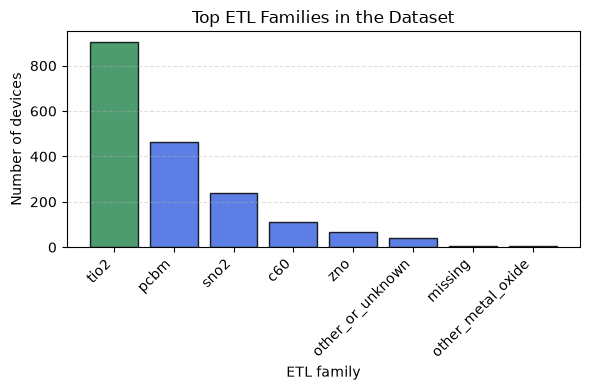

In [21]:
etl_counts = arch["etl_family"].value_counts(dropna=False)

 
plt.figure(figsize=(6,4))
colors = ["royalblue"] * len(etl_counts)  
colors[0] = "seagreen"  
bars = plt.bar(etl_counts.index.astype(str),etl_counts.values,color=colors,edgecolor="black",alpha=0.85)

plt.xlabel("ETL family")
plt.ylabel("Number of devices")
plt.title("Top ETL Families in the Dataset")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "etl_distribution.png"), dpi=600)
plt.show()

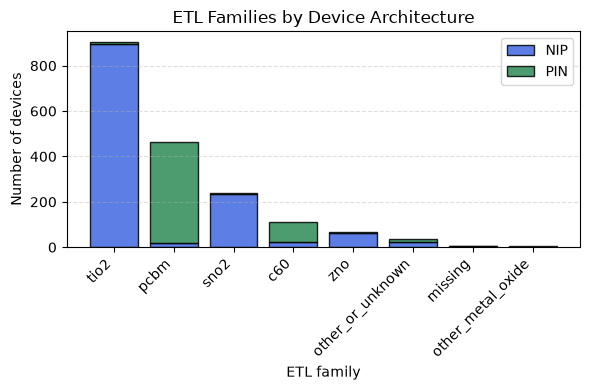

In [22]:
tmp = arch.dropna(subset=["etl_family", "Cell_architecture"]).copy()

tmp["etl_family"] = tmp["etl_family"].fillna("Unknown").astype(str)
tmp["arch_clean"] = (
    tmp["Cell_architecture"]
    .astype(str)
    .str.strip()
    .str.lower()
)

tmp = tmp[tmp["arch_clean"].isin(["nip", "pin"])].copy()

etl_arch_counts = (
    tmp.groupby(["etl_family", "arch_clean"])
       .size()
       .unstack(fill_value=0)
)

# Corrected line
etl_arch_counts = etl_arch_counts.reindex(top_etl.index, fill_value=0)

plt.figure(figsize=(6,4))

plt.bar(
    etl_arch_counts.index,
    etl_arch_counts["nip"],
    color="royalblue",
    edgecolor="black",
    alpha=0.85,
    label="NIP"
)

plt.bar(
    etl_arch_counts.index,
    etl_arch_counts["pin"],
    bottom=etl_arch_counts["nip"],
    color="seagreen",
    edgecolor="black",
    alpha=0.85,
    label="PIN"
)

plt.xlabel("ETL family")
plt.ylabel("Number of devices")
plt.title("ETL Families by Device Architecture")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(ARTIFACT_DIR, "etl_architecture_stacked.png"),
    dpi=600
)

plt.show()

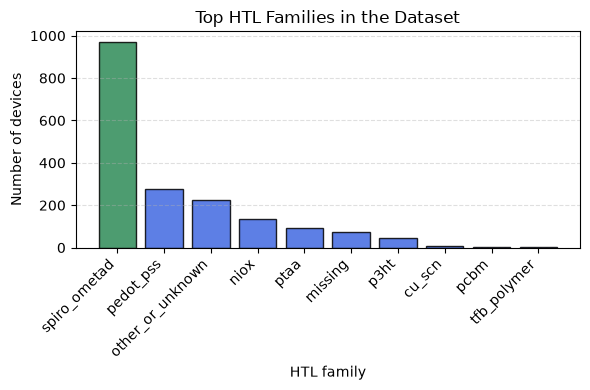

In [23]:
htl_counts = arch["htl_family"].fillna("Unknown").value_counts(dropna=False)

plt.figure(figsize=(6,4))

colors = ["royalblue"] * len(htl_counts)
colors[0] = "seagreen"

bars = plt.bar( htl_counts.index.astype(str), htl_counts.values,color=colors,edgecolor="black", alpha=0.85)

plt.xlabel("HTL family")
plt.ylabel("Number of devices")
plt.title("Top HTL Families in the Dataset")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)



plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "htl_distribution.png"), dpi=600)
plt.show()

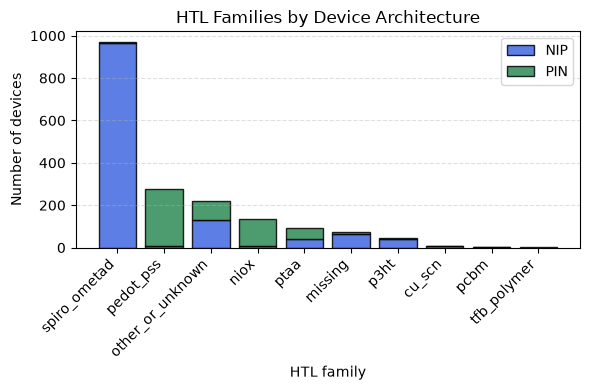

In [24]:
tmp = arch.dropna(subset=["htl_family", "Cell_architecture"]).copy()

tmp["htl_family"] = tmp["htl_family"].fillna("Unknown").astype(str)

tmp["arch_clean"] = ( tmp["Cell_architecture"].astype(str).str.strip().str.lower())
tmp = tmp[tmp["arch_clean"].isin(["nip", "pin"])].copy()

htl_arch_counts = (tmp.groupby(["htl_family", "arch_clean"]).size().unstack(fill_value=0))

htl_arch_counts = htl_arch_counts.loc[htl_arch_counts.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(6,4))

plt.bar(htl_arch_counts.index.astype(str),htl_arch_counts["nip"],color="royalblue", edgecolor="black",alpha=0.85,label="NIP")

plt.bar(htl_arch_counts.index.astype(str),htl_arch_counts["pin"],bottom=htl_arch_counts["nip"],color="seagreen",edgecolor="black",alpha=0.85, label="PIN")

plt.xlabel("HTL family")
plt.ylabel("Number of devices")
plt.title("HTL Families by Device Architecture")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "htl_architecture_stacked.png"), dpi=600)
plt.show()

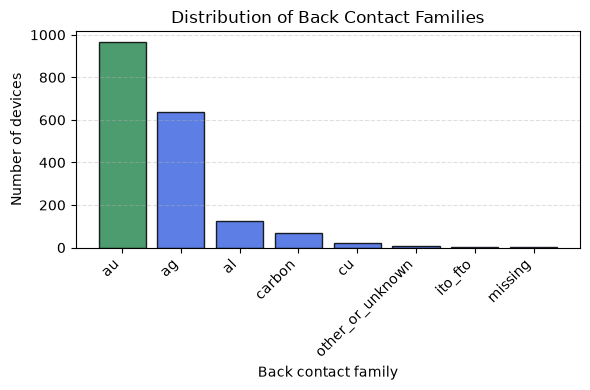

In [25]:
back_counts = arch["backcontact_family"].value_counts(dropna=False)

plt.figure(figsize=(6,4))


colors = ["royalblue"] * len(back_counts)
colors[0] = "seagreen"

bars = plt.bar(back_counts.index.astype(str),back_counts.values,color=colors,edgecolor="black",alpha=0.85)

plt.xlabel("Back contact family")
plt.ylabel("Number of devices")
plt.title("Distribution of Back Contact Families")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "backcontact_distribution.png"), dpi=600)
plt.show()

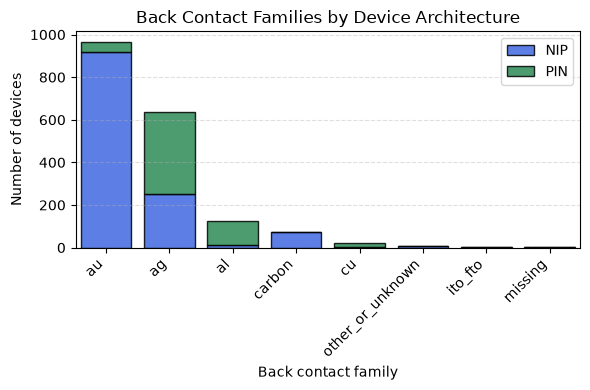

In [26]:
tmp = arch.dropna(subset=["backcontact_family", "Cell_architecture"]).copy()

tmp["backcontact_family"] = tmp["backcontact_family"].astype(str)

tmp["arch_clean"] = (tmp["Cell_architecture"].astype(str).str.strip().str.lower())

tmp = tmp[tmp["arch_clean"].isin(["nip", "pin"])].copy()

back_arch_counts = (tmp.groupby(["backcontact_family", "arch_clean"]).size().unstack(fill_value=0))


back_arch_counts = back_arch_counts.loc[back_arch_counts.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(6,4))

plt.bar(back_arch_counts.index.astype(str),back_arch_counts["nip"],color="royalblue",edgecolor="black",alpha=0.85,label="NIP")
plt.bar(back_arch_counts.index.astype(str),back_arch_counts["pin"],bottom=back_arch_counts["nip"],color="seagreen",edgecolor="black",alpha=0.85,label="PIN")

plt.xlabel("Back contact family")
plt.ylabel("Number of devices")
plt.title("Back Contact Families by Device Architecture")

plt.xticks(rotation=45, ha="right")  # مهم إذا الفئات كثيرة
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.margins(x=0.01)
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "backcontact_architecture.png"),dpi=600)
plt.show()

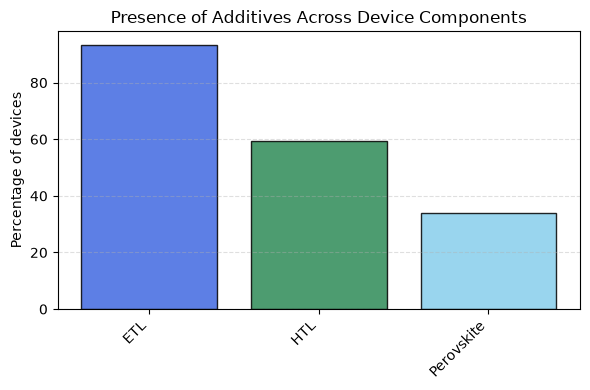

In [27]:
additive_cols = [
    "has_perovskite_additives",
    "has_etl_additives",
    "has_htl_additives"]

additive_ratio = arch[additive_cols].mean().sort_values(ascending=False) * 100

labels = {
    "has_perovskite_additives": "Perovskite",
    "has_etl_additives": "ETL",
    "has_htl_additives": "HTL"}

additive_ratio.index = [labels[col] for col in additive_ratio.index]

plt.figure(figsize=(6,4))

colors = ["royalblue", "seagreen", "skyblue"]

bars = plt.bar(additive_ratio.index,additive_ratio.values,color=colors,edgecolor="black",alpha=0.85)

plt.ylabel("Percentage of devices")
plt.title("Presence of Additives Across Device Components")

plt.xticks(rotation=45, ha="right")


plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "additives_presence.png"), dpi=600)
plt.show()

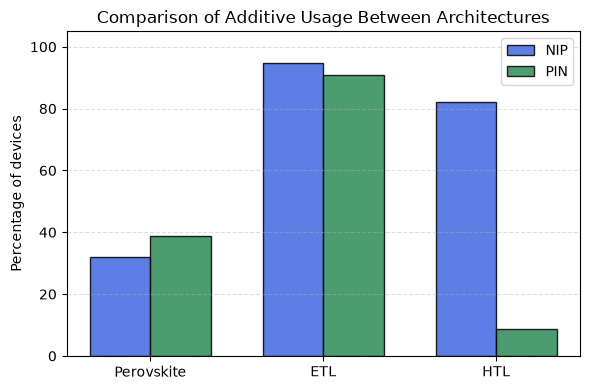

In [28]:
tmp = arch.dropna(subset=["Cell_architecture"]).copy()

tmp["arch_clean"] = (tmp["Cell_architecture"].astype(str).str.strip().str.lower())
tmp = tmp[tmp["arch_clean"].isin(["nip", "pin"])].copy()

additive_cols = [
    "has_perovskite_additives",
    "has_etl_additives",
    "has_htl_additives"]

additive_by_arch = (tmp.groupby("arch_clean")[additive_cols].mean()* 100)

additive_by_arch = additive_by_arch[
    ["has_perovskite_additives", "has_etl_additives", "has_htl_additives"]]

additive_by_arch.columns = ["Perovskite", "ETL", "HTL"]

x = np.arange(len(additive_by_arch.columns))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, additive_by_arch.loc["nip"], width=width,color="royalblue",edgecolor="black", alpha=0.85,label="NIP")

plt.bar(x + width/2,additive_by_arch.loc["pin"], width=width, color="seagreen",edgecolor="black",alpha=0.85,label="PIN")

plt.ylabel("Percentage of devices")
plt.title("Comparison of Additive Usage Between Architectures")
plt.xticks(x, additive_by_arch.columns)
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()


plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "additives_by_architecture.png"), dpi=600)
plt.show()

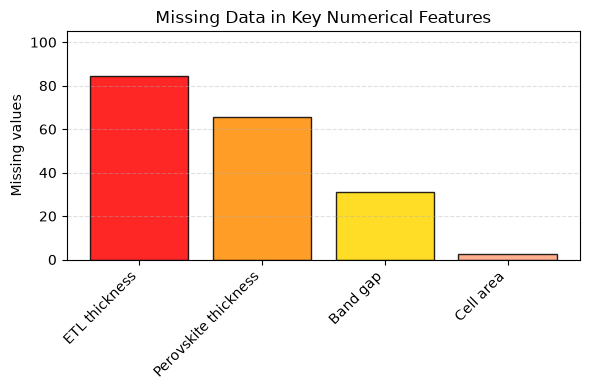

In [29]:
missing_cols = [
    "band_gap_ev",
    "perovskite_thickness_nm",
    "etl_thickness_nm",
    "cell_area_measured_cm2"
]

missing_ratio = arch[missing_cols].isna().mean().sort_values(ascending=False) * 100

labels = {
    "band_gap_ev": "Band gap",
    "perovskite_thickness_nm": "Perovskite thickness",
    "etl_thickness_nm": "ETL thickness",
    "cell_area_measured_cm2": "Cell area"}

missing_ratio.index = [labels[col] for col in missing_ratio.index]

plt.figure(figsize=(6,4))

colors = ["red", "darkorange", "gold", "lightsalmon"]

bars = plt.bar( missing_ratio.index,missing_ratio.values,color=colors[:len(missing_ratio)],edgecolor="black", alpha=0.85)

plt.ylabel("Missing values")
plt.title("Missing Data in Key Numerical Features")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "missing_data.png"), dpi=600)
plt.show()